# Battery Report

Analysis of one or more CarbonShift solver battery runs.

Configure `RESULT_CSVS` in the next cell to point at the `battery_results_*.csv`
files you want to analyse.  All files are merged into a single DataFrame; a
`battery_id` column is added automatically from the file name.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams["figure.dpi"] = 96
plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Configure these paths (absolute or relative to the notebook location) ──────

RESULT_CSVS: list[str | Path] = [
    "results/battery_results_default.csv",
]

# ── Mode filter: which infeasibility modes to include in plots ───────────────
#   "greedy_fallback" | "relaxed_retry" | "both"
SHOW_MODES: str = "both"

# ── Visual styles for alternative strategies ─────────────────────────────────
STRATEGY_STYLE: dict = {
    "greedy_cheapest": {"color": "tab:green",  "marker": "D"},
    "bandit":          {"color": "tab:purple", "marker": "^"},
    "ant_colony":      {"color": "tab:cyan",   "marker": "*"},
}
_STRATEGY_FALLBACK_COLORS = ["tab:brown", "tab:pink", "tab:olive"]

# ── Metrics to plot ───────────────────────────────────────────────────────────
METRICS: list[dict] = [
    {"col": "solver_time_ms_avg",              "label": "Solver time (ms avg)"},
    {"col": "total_carbon_cost",               "label": "Total carbon cost"},
    {"col": "final_global_error",              "label": "Final global error"},
    {"col": "avg_global_error_per_slot",       "label": "Avg global error / slot"},
    {"col": "carbon_cost_saving_vs_baseline_pct", "label": "Carbon saving vs baseline (%)"},
    {"col": "total_rollbacks",                 "label": "Total rollbacks (Rust only)"},
    {"col": "max_consecutive_rollbacks",       "label": "Max consecutive rollbacks"},
    {"col": "peak_concurrent_workers",         "label": "Peak concurrent workers"},
    {"col": "avg_concurrent_workers",          "label": "Avg concurrent workers"},
]

MODE_STYLE: dict = {
    "greedy_fallback": {"linestyle": "-",  "marker": "o"},
    "relaxed_retry":   {"linestyle": "--", "marker": "s"},
}

BACKEND_COLOR: dict = {
    "python": {"greedy_fallback": "tab:blue",   "relaxed_retry": "tab:cyan"},
    "rust":   {"greedy_fallback": "tab:orange", "relaxed_retry": "tab:red"},
}


In [2]:
_nb_dir = Path(__file__) if "__file__" in dir() else Path.cwd()

frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Results CSV not found: {p}")
    _df = pd.read_csv(p)
    stem = p.stem
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    _df.insert(0, "battery_id", bid)
    frames.append(_df)

df = pd.concat(frames, ignore_index=True)
df["batch_size"] = df["batch_size"].astype(int)

for _rb_col in ("total_rollbacks", "max_consecutive_rollbacks",
                "peak_concurrent_workers", "avg_concurrent_workers"):
    if _rb_col not in df.columns:
        df[_rb_col] = 0
df["total_rollbacks"] = df["total_rollbacks"].fillna(0).astype(int)
df["max_consecutive_rollbacks"] = df["max_consecutive_rollbacks"].fillna(0).astype(int)

# ── Identify strategies vs. infeasibility modes ───────────────────────────────
_KNOWN_MODES = {"greedy_fallback", "relaxed_retry"}
STRATEGY_NAMES: list[str] = sorted(set(df["infeasibility_mode"].unique()) - _KNOWN_MODES)

df_modes = df[df["infeasibility_mode"].isin(_KNOWN_MODES)].copy()
df_strat = df[~df["infeasibility_mode"].isin(_KNOWN_MODES)].copy()

# Apply SHOW_MODES filter
if SHOW_MODES == "greedy_fallback":
    df_modes = df_modes[df_modes["infeasibility_mode"] == "greedy_fallback"].copy()
elif SHOW_MODES == "relaxed_retry":
    df_modes = df_modes[df_modes["infeasibility_mode"] == "relaxed_retry"].copy()

scenarios   = sorted(df["scenario_id"].unique())
batch_sizes = sorted(df_modes["batch_size"].unique())
combos = sorted(
    df_modes[["backend", "infeasibility_mode"]].drop_duplicates().itertuples(index=False, name=None)
)

def _xaxis_info():
    """Build categorical x-axis covering batch sizes then strategies."""
    labels     = [f"N={n}" for n in batch_sizes] + STRATEGY_NAMES
    bs_to_x    = {n: i for i, n in enumerate(batch_sizes)}
    strat_to_x = {s: len(batch_sizes) + i for i, s in enumerate(STRATEGY_NAMES)}
    return labels, bs_to_x, strat_to_x, len(batch_sizes)

x_labels, bs_to_x, strat_to_x, n_bs = _xaxis_info()

print(f"Loaded {len(df)} rows from {len(frames)} CSV file(s).")
print(f"Batteries   : {sorted(df['battery_id'].unique())}")
print(f"Scenarios   : {scenarios}")
print(f"Backends    : {sorted(df['backend'].unique())}")
print(f"Modes shown : {sorted(df_modes['infeasibility_mode'].unique())} (SHOW_MODES={SHOW_MODES!r})")
print(f"Strategies  : {STRATEGY_NAMES}")
print(f"Batch sizes : {batch_sizes}")

df


Loaded 91 rows from 1 CSV file(s).
Batteries   : ['default']
Scenarios   : ['high_load_105', 'high_load_92', 'low_load_2028', 'low_load_2030', 'medium_load_2028', 'medium_load_38', 'xhigh_load_120']
Backends    : ['rust']
Modes shown : ['greedy_fallback', 'relaxed_retry'] (SHOW_MODES='both')
Strategies  : ['ant_colony', 'bandit', 'greedy_cheapest']
Batch sizes : [np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]


,battery_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,total_carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline_pct,peak_concurrent_workers,avg_concurrent_workers
0,default,low_load_2028,rust,1,greedy_fallback,3.2299,1150.7399,3.9832,3.9804,0,0,49,1,4841.5281,76.2319,20,8.7454
1,default,low_load_2028,rust,4,greedy_fallback,3.9890,1099.4459,3.9884,3.9985,0,0,208,4,4841.5281,77.2913,10,3.1339
2,default,low_load_2028,rust,6,greedy_fallback,10.5107,1213.8852,3.9586,3.9556,0,0,124,3,4841.5281,74.9276,6,2.0778
3,default,low_load_2028,rust,8,greedy_fallback,17.3939,1259.5492,3.9376,3.9283,0,0,80,3,4841.5281,73.9845,5,1.6538
4,default,low_load_2028,rust,10,greedy_fallback,21.7242,1247.2918,3.9323,3.9196,0,0,51,2,4841.5281,74.2376,4,1.4046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,default,xhigh_load_120,rust,8,relaxed_retry,32.7402,8253.8134,3.9386,3.9372,0,1755,741,4,28601.7519,71.1423,20,9.0821
87,default,xhigh_load_120,rust,10,relaxed_retry,57.6077,8204.4241,3.9381,3.9289,0,1747,744,4,28601.7519,71.3150,20,7.3479
88,default,xhigh_load_120,rust,0,greedy_cheapest,0.0000,9235.6916,3.9256,3.9167,0,0,0,0,28601.7519,67.7094,0,0.0000
89,default,xhigh_load_120,rust,0,bandit,0.0000,4047.5364,5.0000,5.0000,0,0,0,0,28601.7519,85.8486,0,0.0000


## Execution timings

Wall-clock time per scenario and total battery run time, read from
`battery_timings_*.csv` files that mirror the `RESULT_CSVS` list above.


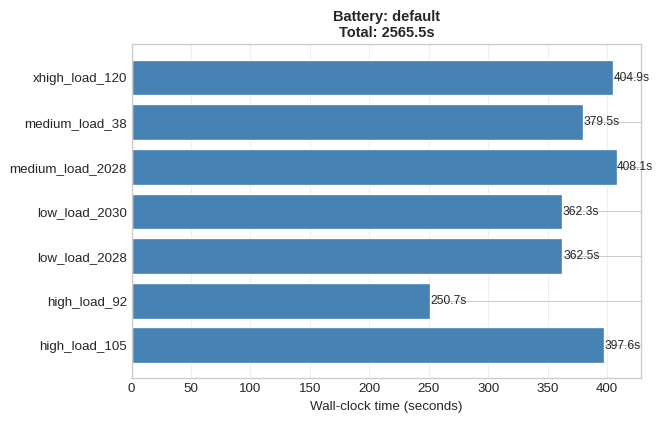


Per-battery totals:
  default: 2565.5s

### Strategy execution times (ms)


/tmp/ipykernel_1400993/2192535866.py:62: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_val = float(row["mean"])
/tmp/ipykernel_1400993/2192535866.py:63: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  min_val  = float(row["min"])
/tmp/ipykernel_1400993/2192535866.py:64: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_val  = float(row["max"])


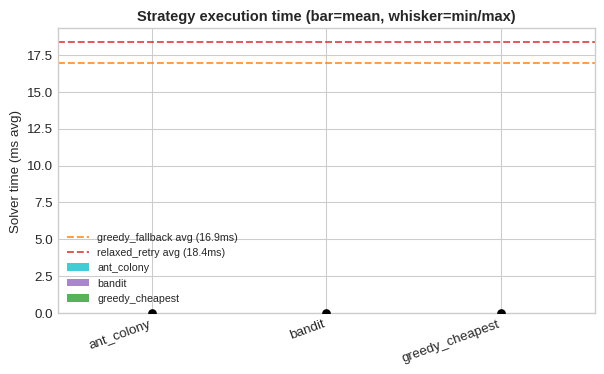

,strategy,min,mean,max
0,ant_colony,0.0000,0.0000,0.0000
1,bandit,0.0000,0.0000,0.0000
2,greedy_cheapest,0.0000,0.0000,0.0000


In [3]:
timing_frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    stem = p.stem
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    timing_path = p.parent / f"battery_timings{('_' + bid) if bid != 'unnamed' else ''}.csv"
    if not timing_path.exists():
        print(f"WARNING: timing file not found: {timing_path}")
        continue
    _t = pd.read_csv(timing_path)
    _t.insert(0, "battery_id", bid)
    timing_frames.append(_t)

if not timing_frames:
    print("No timing files found – run the battery first to generate timings.")
else:
    tdf = pd.concat(timing_frames, ignore_index=True)
    scenario_times = tdf[tdf["scenario_id"] != "__battery_total__"].copy()
    battery_totals = tdf[tdf["scenario_id"] == "__battery_total__"].copy()
    battery_ids = scenario_times["battery_id"].unique().tolist()
    n_batteries = len(battery_ids)

    fig, axes = plt.subplots(1, n_batteries, figsize=(max(7, 5 * n_batteries), 4.5), squeeze=False)
    for ax, bid in zip(axes[0], battery_ids):
        sub = scenario_times[scenario_times["battery_id"] == bid].sort_values("scenario_id")
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        total_s = float(total_row["elapsed_seconds"].iloc[0]) if not total_row.empty else sub["elapsed_seconds"].sum()
        bars = ax.barh(sub["scenario_id"], sub["elapsed_seconds"], color="steelblue", edgecolor="white")
        for bar, val in zip(bars, sub["elapsed_seconds"]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}s", va="center", fontsize=9)
        ax.set_xlabel("Wall-clock time (seconds)")
        ax.set_title(f"Battery: {bid}\nTotal: {total_s:.1f}s", fontsize=11, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("\nPer-battery totals:")
    for bid in battery_ids:
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        if not total_row.empty:
            print(f"  {bid}: {float(total_row['elapsed_seconds'].iloc[0]):.1f}s")

# ── Strategy execution timing ─────────────────────────────────────────────────
if not df_strat.empty and "solver_time_ms_avg" in df_strat.columns:
    print("\n### Strategy execution times (ms)")
    timing_strat = (
        df_strat
        .groupby("infeasibility_mode")["solver_time_ms_avg"]
        .agg(min="min", mean="mean", max="max")
        .reset_index()
        .rename(columns={"infeasibility_mode": "strategy"})
    )

    fig, ax = plt.subplots(figsize=(max(4, len(STRATEGY_NAMES) * 1.8 + 1), 4))
    for i, strat in enumerate(STRATEGY_NAMES):
        row = timing_strat[timing_strat["strategy"] == strat]
        if row.empty:
            continue
        mean_val = float(row["mean"])
        min_val  = float(row["min"])
        max_val  = float(row["max"])
        color = STRATEGY_STYLE.get(strat, {}).get("color", _STRATEGY_FALLBACK_COLORS[i % len(_STRATEGY_FALLBACK_COLORS)])
        ax.bar(i, mean_val, color=color, alpha=0.8, label=strat)
        ax.plot([i, i], [min_val, max_val], color="black", linewidth=2.5, zorder=5)
        ax.scatter([i], [mean_val], color="black", s=30, zorder=6)

    # Reference lines: avg solver time for each mode
    if not df_modes.empty:
        mode_colors = {"greedy_fallback": "tab:orange", "relaxed_retry": "tab:red"}
        for mode, grp in df_modes.groupby("infeasibility_mode"):
            avg = grp["solver_time_ms_avg"].mean()
            ax.axhline(avg, linestyle="--", linewidth=1.4, alpha=0.8,
                       color=mode_colors.get(mode, "gray"),
                       label=f"{mode} avg ({avg:.1f}ms)")

    ax.set_xticks(range(len(STRATEGY_NAMES)))
    ax.set_xticklabels(STRATEGY_NAMES, rotation=20, ha="right")
    ax.set_ylabel("Solver time (ms avg)")
    ax.set_title("Strategy execution time (bar=mean, whisker=min/max)", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    display(timing_strat.round(3))
else:
    print("No strategy data loaded – run battery with additional_strategies to see timings.")


## Per-scenario metrics

One figure per scenario.  Each figure shows all metrics; lines are split by
`(backend, infeasibility_mode)` combination.


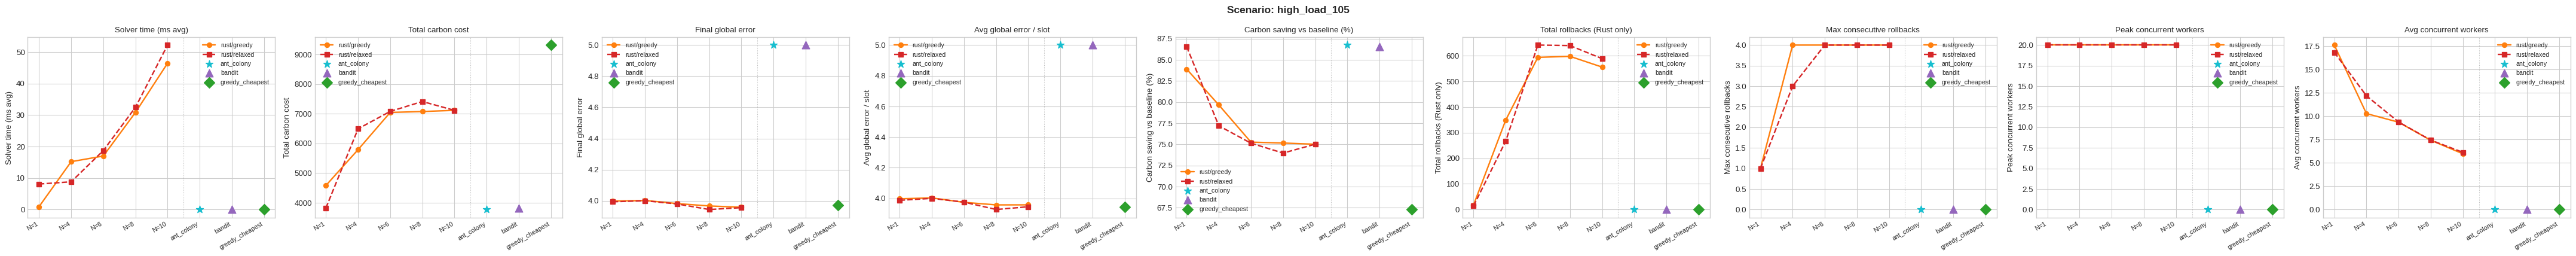

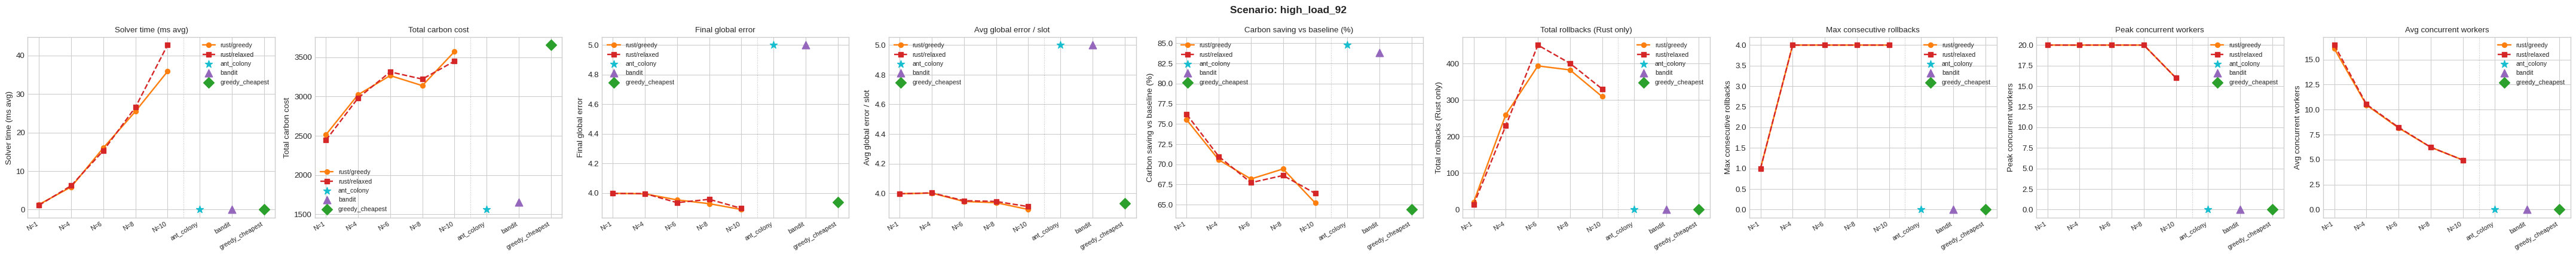

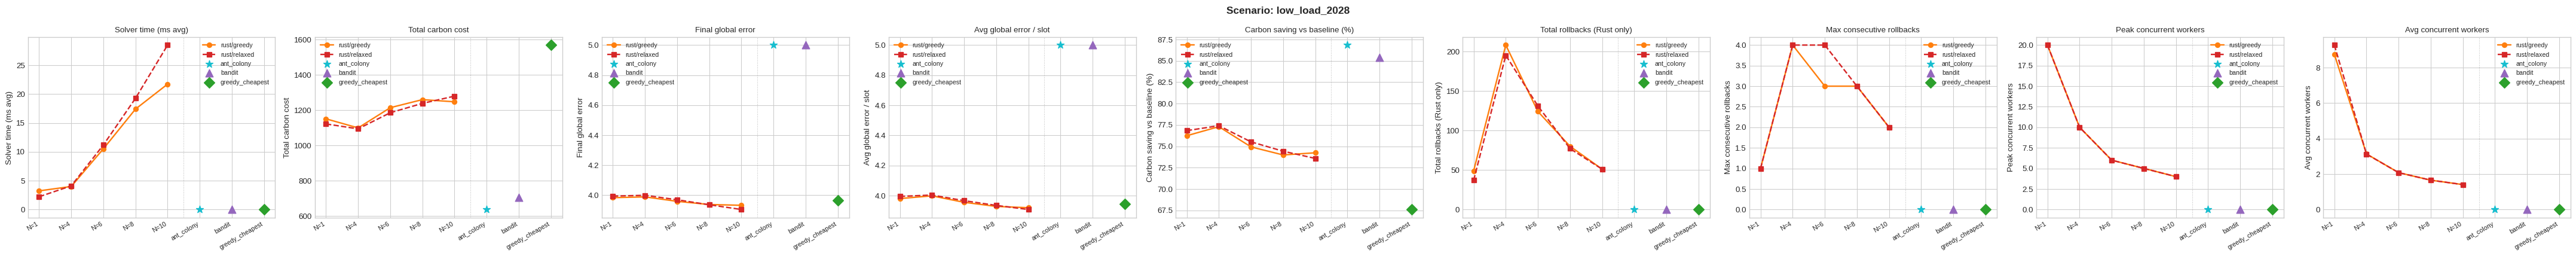

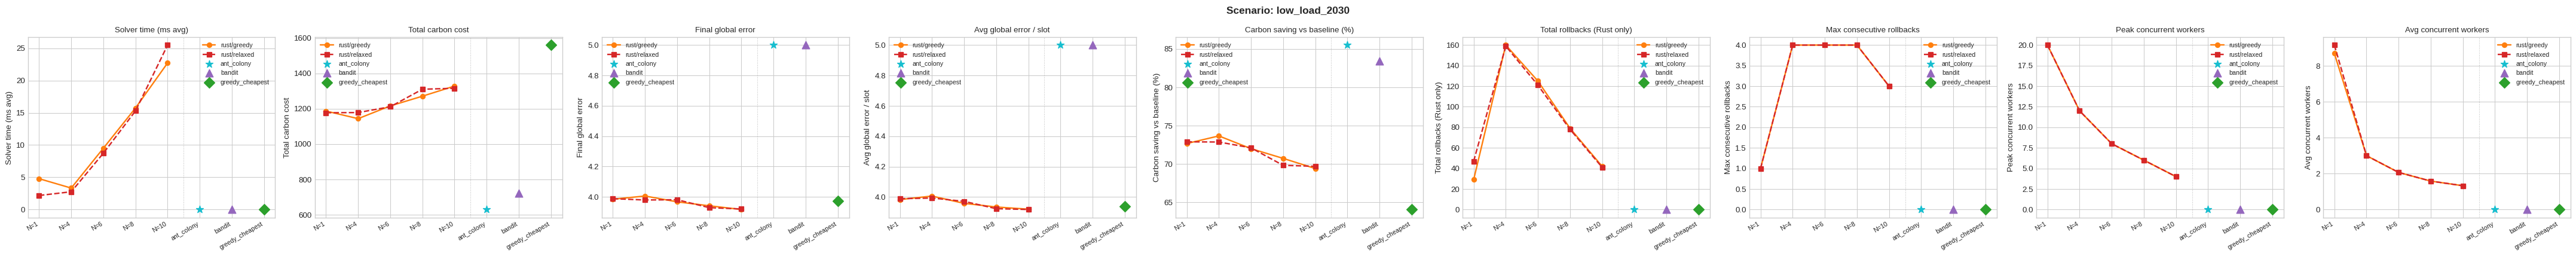

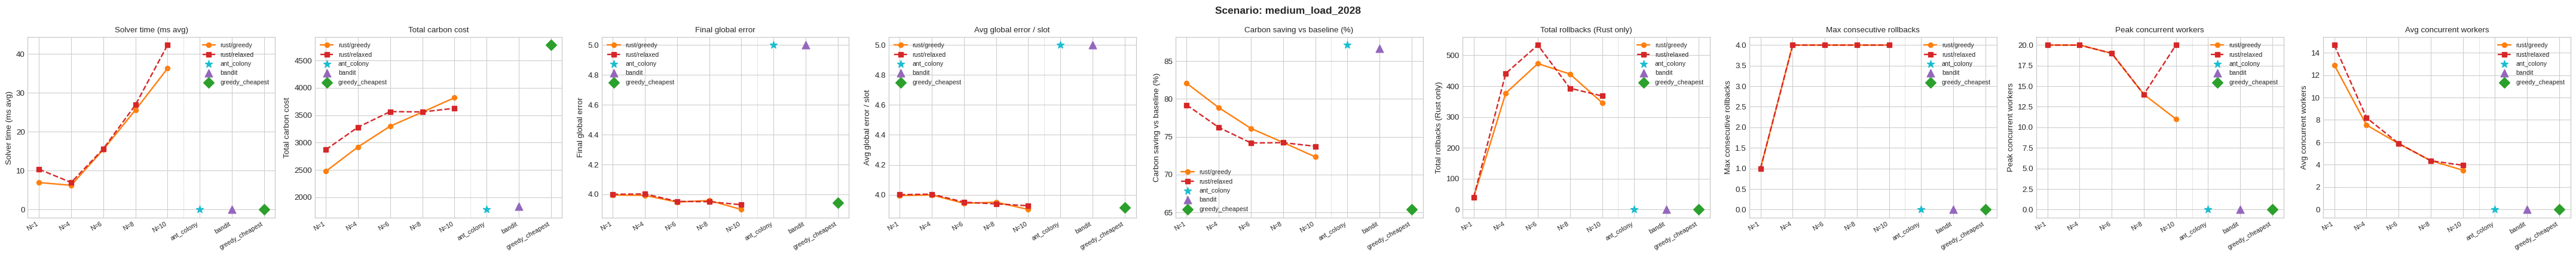

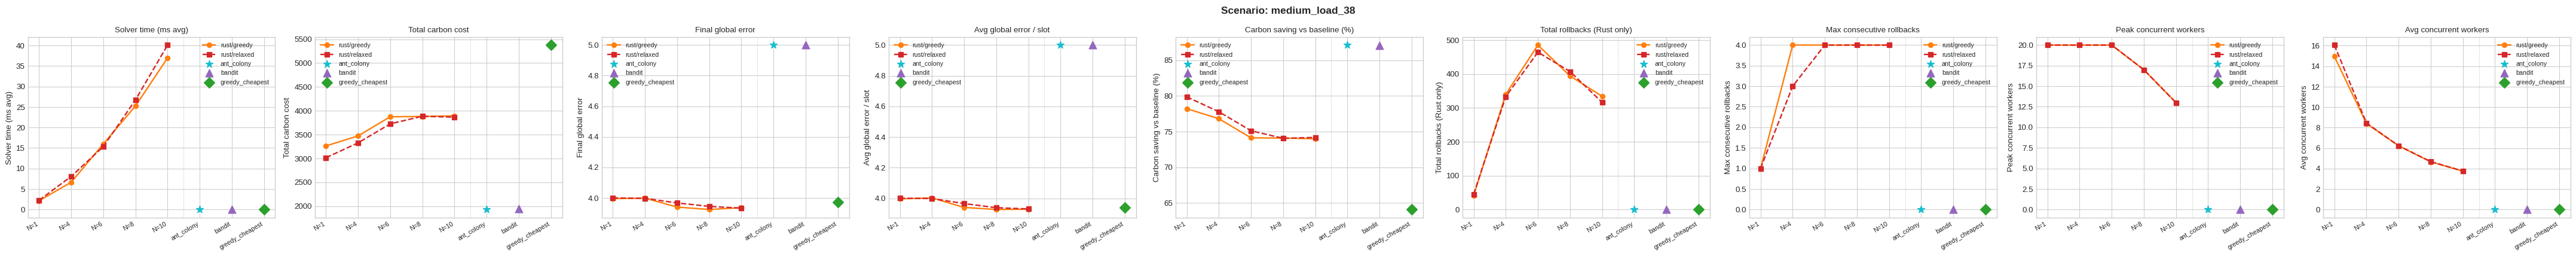

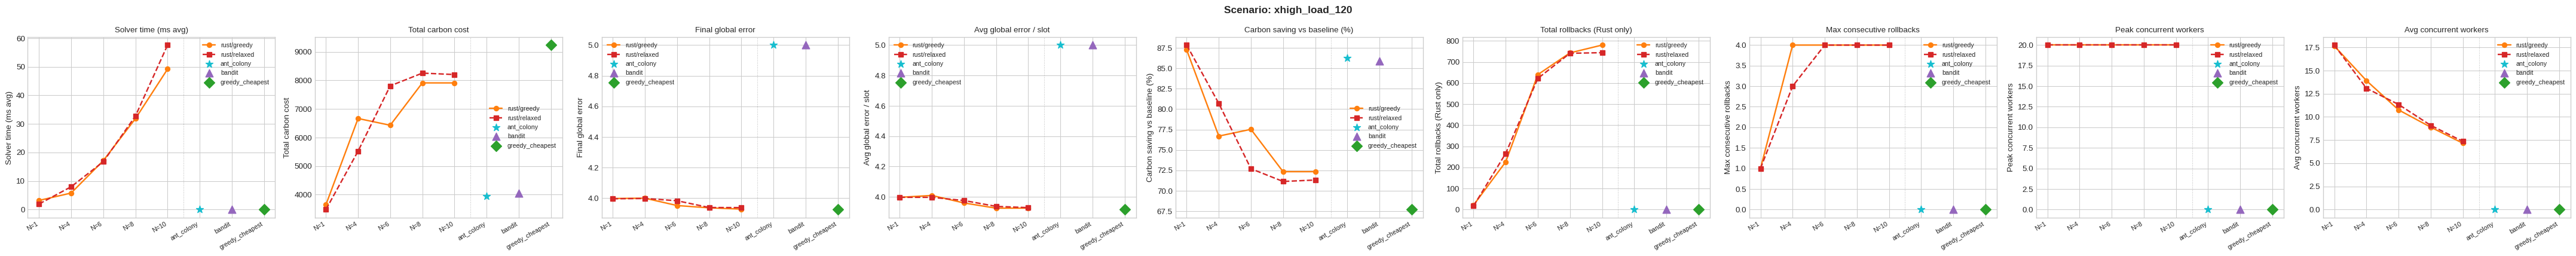

In [4]:
def _series_label(backend: str, mode: str) -> str:
    mode_short = "greedy" if mode == "greedy_fallback" else "relaxed"
    return f"{backend}/{mode_short}"

def _series_style(backend: str, mode: str) -> dict:
    color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
    style = MODE_STYLE.get(mode, {})
    return {"color": color, **style}

def _strategy_style(name: str) -> dict:
    if name in STRATEGY_STYLE:
        return STRATEGY_STYLE[name]
    i = STRATEGY_NAMES.index(name) % len(_STRATEGY_FALLBACK_COLORS)
    return {"color": _STRATEGY_FALLBACK_COLORS[i], "marker": "X"}

def _apply_xaxis(ax, rotate=30):
    if STRATEGY_NAMES and n_bs > 0:
        ax.axvline(x=n_bs - 0.5, linestyle=":", linewidth=0.8, alpha=0.5, color="gray")
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=rotate, ha="right", fontsize=8)

n_metrics = len(METRICS)

for sid in scenarios:
    s_df_m = df_modes[df_modes["scenario_id"] == sid].sort_values("batch_size")
    s_df_s = df_strat[df_strat["scenario_id"] == sid] if not df_strat.empty else pd.DataFrame()

    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4.5))
    if n_metrics == 1:
        axes = [axes]
    fig.suptitle(f"Scenario: {sid}", fontsize=13, fontweight="bold")

    for ax, m in zip(axes, METRICS):
        for backend, mode in combos:
            sub = s_df_m[(s_df_m["backend"] == backend) & (s_df_m["infeasibility_mode"] == mode)]
            if sub.empty:
                continue
            xs = [bs_to_x[bs] for bs in sub["batch_size"]]
            ax.plot(xs, sub[m["col"]].values,
                    label=_series_label(backend, mode), linewidth=1.8,
                    **_series_style(backend, mode))

        for strat in STRATEGY_NAMES:
            if s_df_s.empty:
                continue
            sub_s = s_df_s[s_df_s["infeasibility_mode"] == strat]
            if sub_s.empty or m["col"] not in sub_s.columns:
                continue
            sty = _strategy_style(strat)
            ax.scatter([strat_to_x[strat]], [sub_s[m["col"]].values[0]],
                       label=strat, s=90, zorder=5,
                       color=sty["color"], marker=sty["marker"])

        _apply_xaxis(ax)
        ax.set_ylabel(m["label"])
        ax.set_title(m["label"], fontsize=10)
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


## All scenarios on one chart

Each metric is shown in a single figure with one subplot per `(backend, infeasibility_mode)`
combination.  All scenarios appear as separate lines to allow direct comparison.


/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


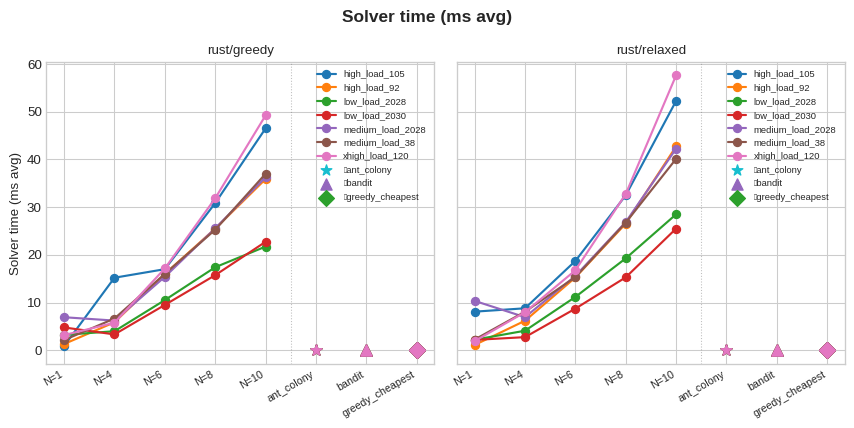

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


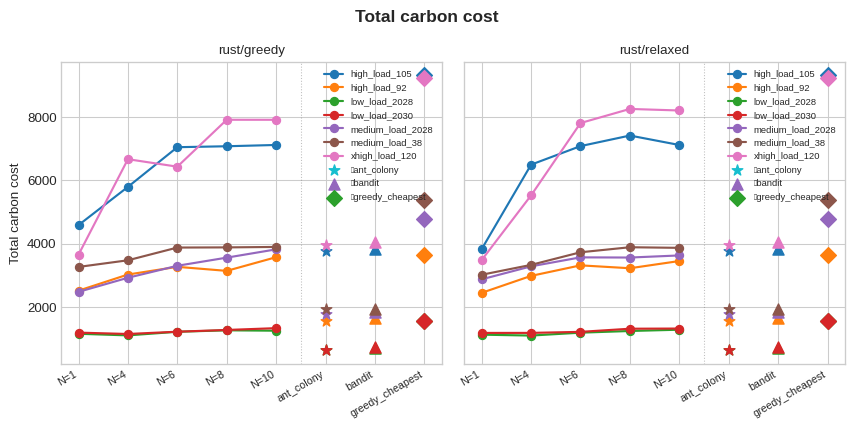

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


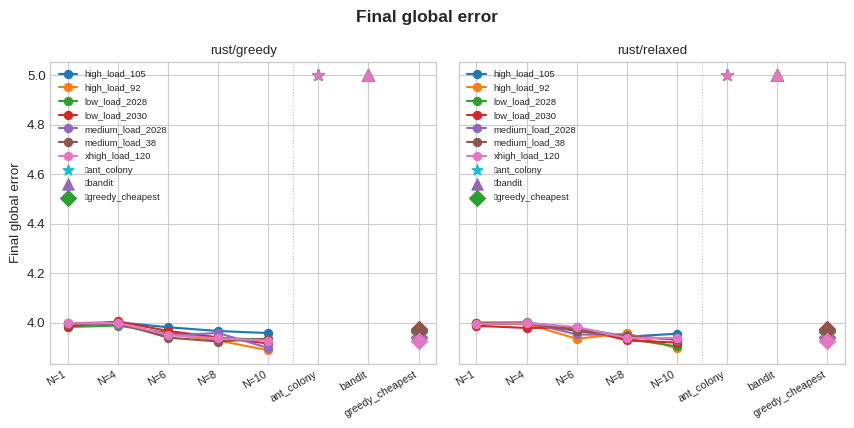

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


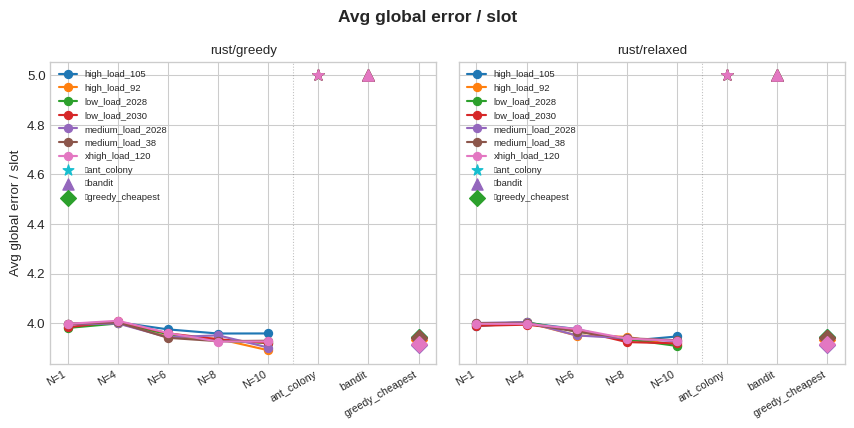

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


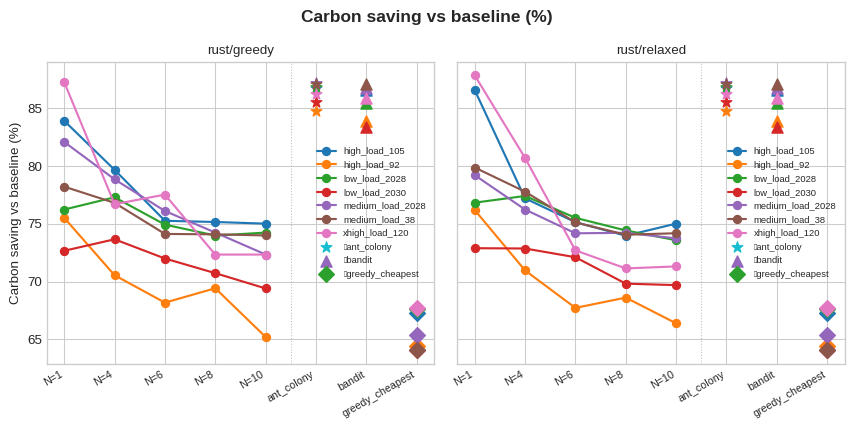

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


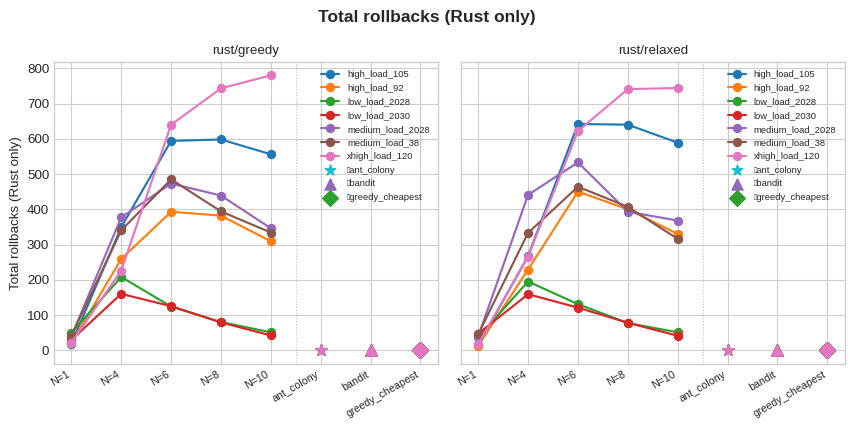

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


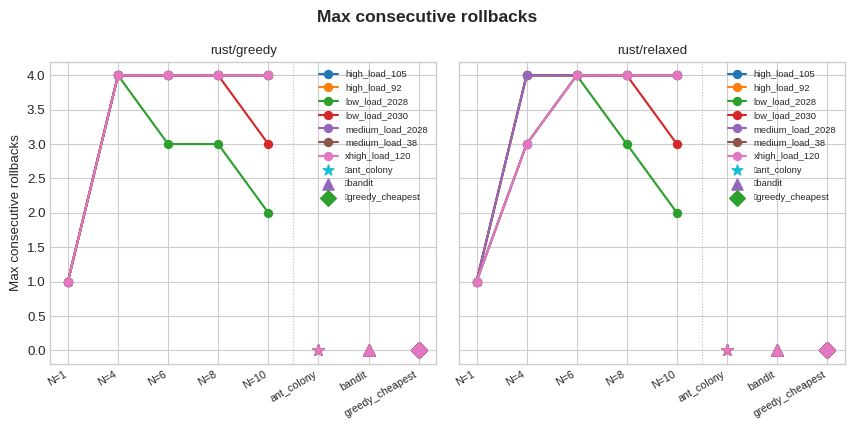

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


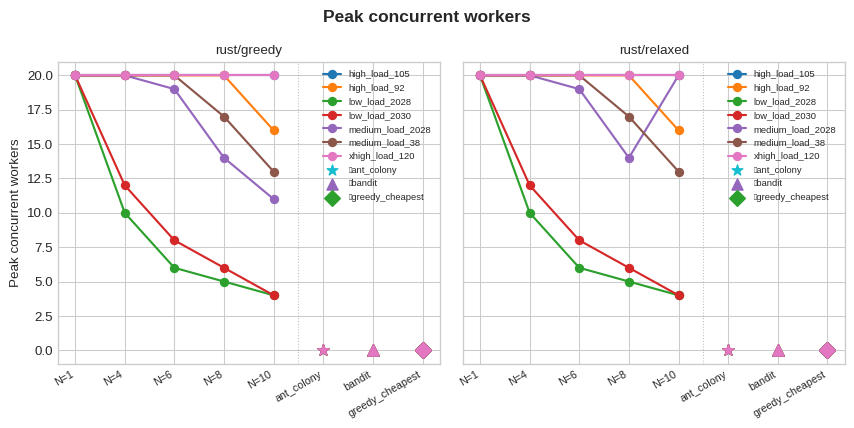

/tmp/ipykernel_1400993/3238617329.py:50: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/francis/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9656 (\N{BLACK RIGHT-POINTING SMALL TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


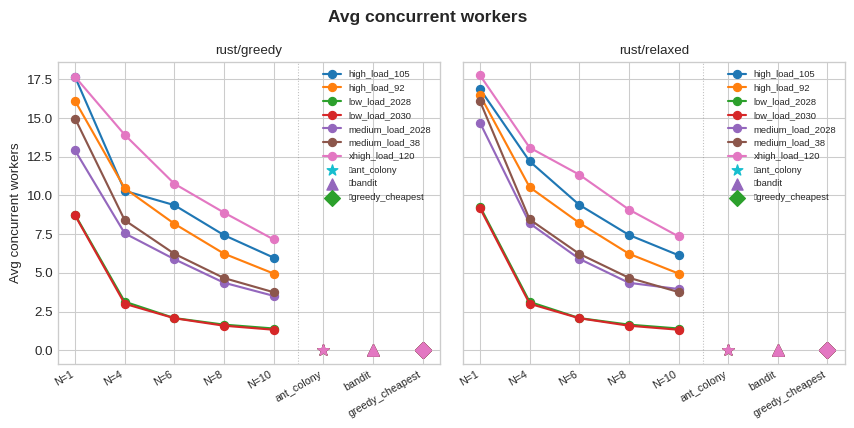

In [5]:
fig_w = max(6, 4.5 * max(len(combos), 1))
colors_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
sid_color = {sid: colors_cycle[i % len(colors_cycle)] for i, sid in enumerate(scenarios)}

for m in METRICS:
    fig, axes = plt.subplots(1, max(len(combos), 1), figsize=(fig_w, 4.5), sharey=True)
    if len(combos) <= 1:
        axes = [axes]
    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    for ax, (backend, mode) in zip(axes, combos):
        ax.set_title(_series_label(backend, mode), fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel(m["label"])

        for sid in scenarios:
            sub = df_modes[
                (df_modes["scenario_id"] == sid) &
                (df_modes["backend"] == backend) &
                (df_modes["infeasibility_mode"] == mode)
            ].sort_values("batch_size")
            if sub.empty:
                continue
            xs = [bs_to_x[bs] for bs in sub["batch_size"]]
            ax.plot(xs, sub[m["col"]].values,
                    marker="o", linewidth=1.6, color=sid_color[sid], label=sid)

        # Strategy points per scenario (same color as scenario, distinct marker)
        for strat in STRATEGY_NAMES:
            for sid in scenarios:
                sub_s = df_strat[
                    (df_strat["scenario_id"] == sid) &
                    (df_strat["infeasibility_mode"] == strat)
                ]
                if sub_s.empty or m["col"] not in sub_s.columns:
                    continue
                sty = _strategy_style(strat)
                ax.scatter([strat_to_x[strat]], [sub_s[m["col"]].values[0]],
                           s=70, zorder=5, color=sid_color[sid], marker=sty["marker"])

        # Strategy legend markers (one entry per strategy, color=gray)
        for strat in STRATEGY_NAMES:
            sty = _strategy_style(strat)
            ax.scatter([], [], s=70, marker=sty["marker"],
                       color=sty["color"], label=f"▸{strat}")

        _apply_xaxis(ax)
        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()


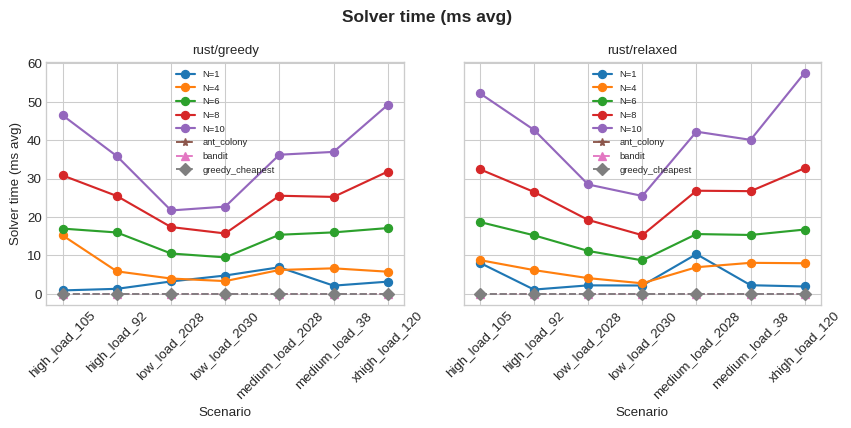

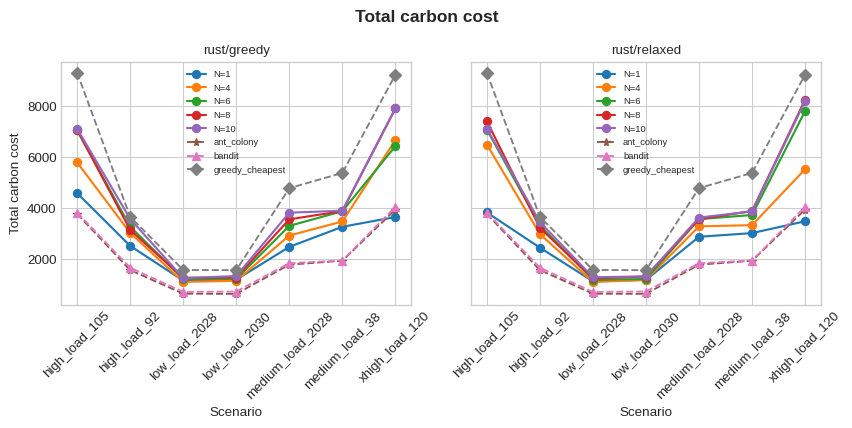

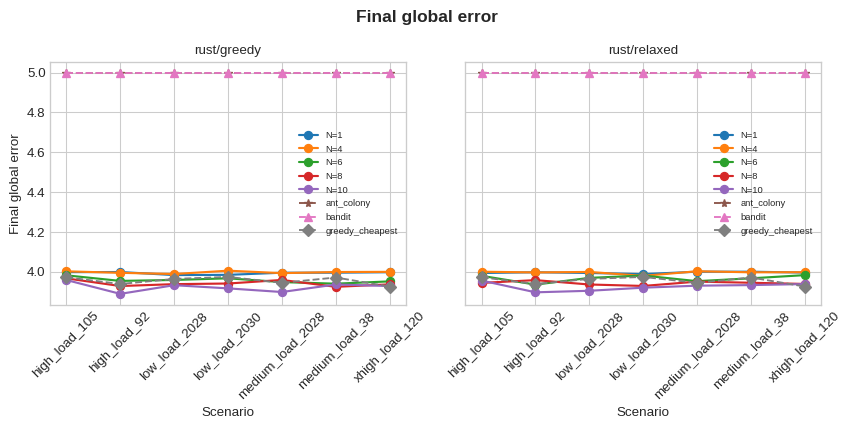

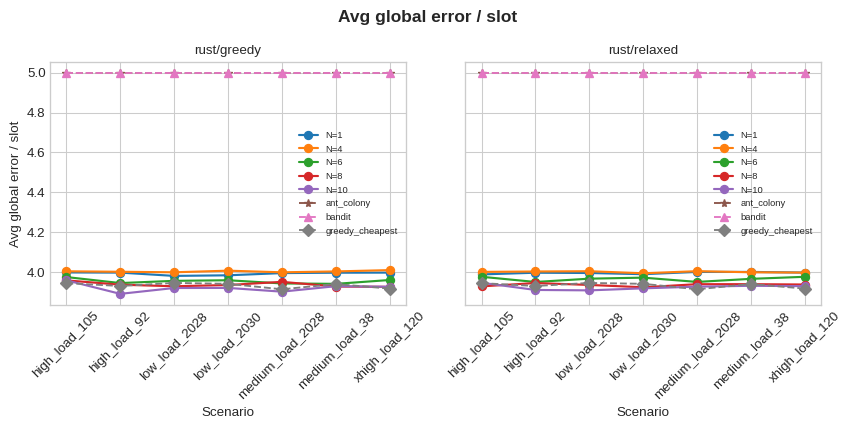

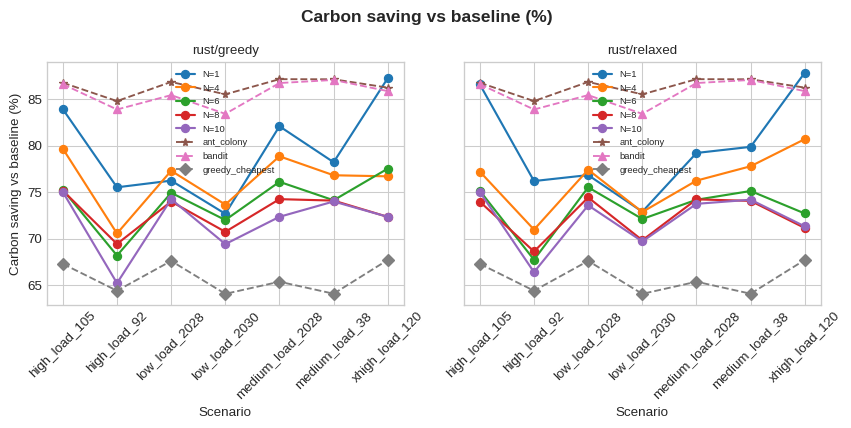

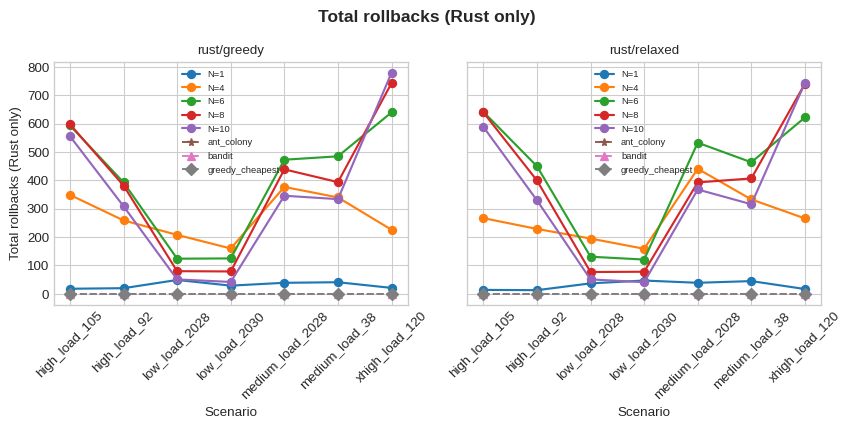

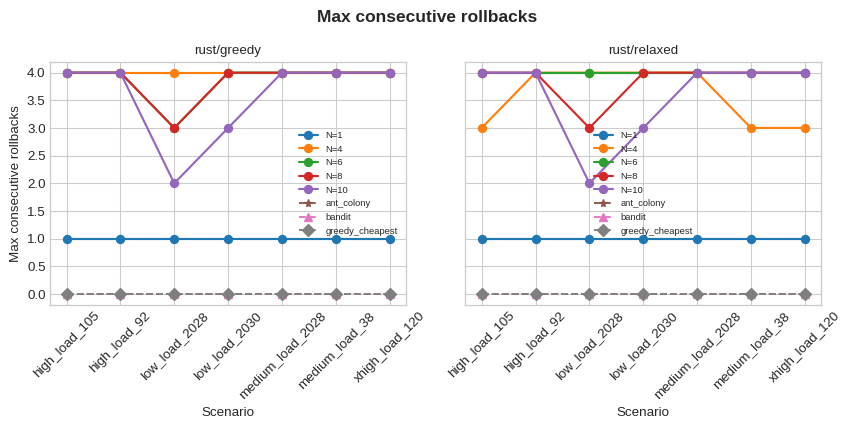

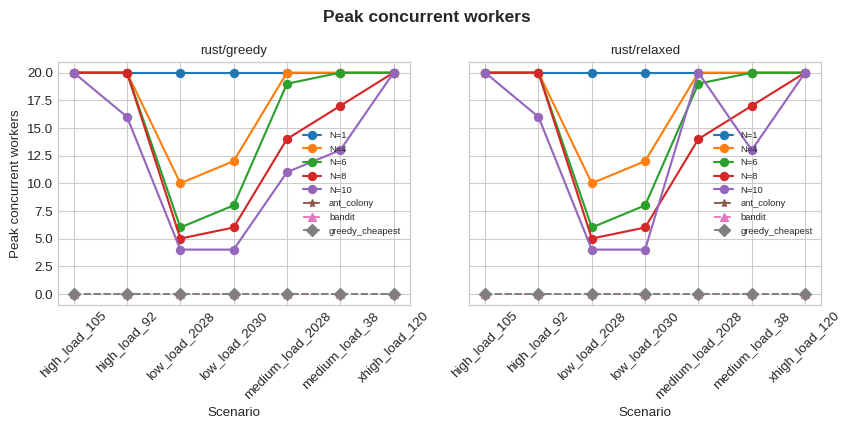

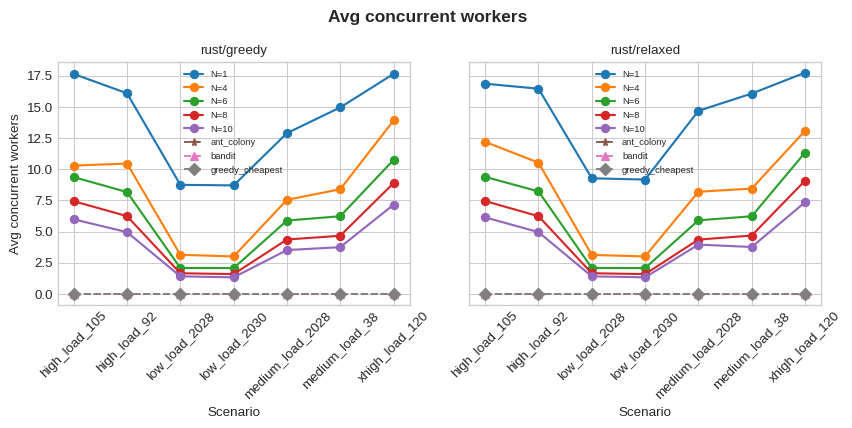

In [6]:
fig_w = max(6, 4.5 * max(len(combos), 1))
colors_cycle2 = plt.rcParams["axes.prop_cycle"].by_key()["color"]
bs_color = {bs: colors_cycle2[i % len(colors_cycle2)] for i, bs in enumerate(batch_sizes)}
strat_color = {
    s: colors_cycle2[(len(batch_sizes) + i) % len(colors_cycle2)]
    for i, s in enumerate(STRATEGY_NAMES)
}

for m in METRICS:
    fig, axes = plt.subplots(1, max(len(combos), 1), figsize=(fig_w, 4.5), sharey=True)
    if len(combos) <= 1:
        axes = [axes]
    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    for ax, (backend, mode) in zip(axes, combos):
        ax.set_title(_series_label(backend, mode), fontsize=10)
        ax.set_xlabel("Scenario")
        if ax is axes[0]:
            ax.set_ylabel(m["label"])

        for bs in batch_sizes:
            sub = (
                df_modes[
                    (df_modes["backend"] == backend) &
                    (df_modes["infeasibility_mode"] == mode) &
                    (df_modes["batch_size"] == bs)
                ]
                .set_index("scenario_id")
                .reindex(scenarios)
            )
            ax.plot(scenarios, sub[m["col"]].values,
                    marker="o", linewidth=1.6, color=bs_color[bs], label=f"N={bs}")

        # Strategies as additional lines (one point per scenario)
        for strat in STRATEGY_NAMES:
            if df_strat.empty:
                continue
            sub_s = (
                df_strat[df_strat["infeasibility_mode"] == strat]
                .set_index("scenario_id")
                .reindex(scenarios)
            )
            if m["col"] not in sub_s.columns:
                continue
            sty = _strategy_style(strat)
            ax.plot(scenarios, sub_s[m["col"]].values,
                    marker=sty["marker"], linewidth=1.4, linestyle="--",
                    color=strat_color[strat], label=strat)

        ax.legend(fontsize=7, loc="best")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


## Aggregate statistics across all scenarios

Min / mean / max of each metric, grouped by `(backend, infeasibility_mode, batch_size)`.


In [7]:
metric_cols = [m["col"] for m in METRICS]
agg_modes = (
    df_modes.groupby(["backend", "infeasibility_mode", "batch_size"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("=== Modes: min / mean / max per (backend, mode, batch_size) ===")
display(agg_modes)

if not df_strat.empty:
    agg_strat = (
        df_strat.groupby(["infeasibility_mode"])[metric_cols]
        .agg(["min", "mean", "max"])
        .round(4)
    )
    print("\n=== Strategies: min / mean / max across all scenarios ===")
    display(agg_strat)


=== Modes: min / mean / max per (backend, mode, batch_size) ===


solver_time_ms_avg                  \
                                                     min    mean     max   
backend infeasibility_mode batch_size                                      
rust    greedy_fallback    1                      0.8957  3.2072  6.9207   
                           4                      3.3233  6.7158 15.1996   
                           6                      9.4992 14.5032 17.1338   
                           8                     15.7314 24.5830 31.8391   
                           10                    21.7242 35.5980 49.1954   
        relaxed_retry      1                      1.1122  4.0148 10.3460   
                           4                      2.7496  6.4026  8.7951   
                           6                      8.7237 14.5033 18.7148   
                           8                     15.2815 25.6989 32.7402   
                           10                    25.4944 41.2702 57.6077   

                                      total_carbon_cost                      \
                                                    min      mean       max   
backend infeasibility_mode batch_size                                         
rust    greedy_fallback    1                  1150.7399 2688.5793 4583.7135   
                           4                  1099.4459 3444.9608 6666.0490   
                           6                  1213.8852 3763.1759 7044.8977   
                           8                  1259.5492 4012.8317 7911.6890   
                           10                 1247.2918 4126.2179 7911.0258   
        relaxed_retry      1                  1121.9240 2562.1355 3825.9315   
                           4                  1094.0025 3410.9344 6493.4718   
                           6                  1185.4246 3983.6885 7807.9633   
                           8                  1238.2591 4125.6116 8253.8134   
                           10                 1279.2014 4121.8978 8204.4241   

                                      final_global_error                \
                                                     min   mean    max   
backend infeasibility_mode batch_size                                    
rust    greedy_fallback    1                      3.9832 3.9931 3.9985   
                           4                      3.9884 3.9973 4.0052   
                           6                      3.9399 3.9572 3.9818   
                           8                      3.9241 3.9418 3.9666   
                           10                     3.8888 3.9226 3.9583   
        relaxed_retry      1                      3.9878 3.9955 4.0001   
                           4                      3.9791 3.9959 4.0024   
                           6                      3.9352 3.9667 3.9829   
                           8                      3.9286 3.9428 3.9577   
                           10                     3.8965 3.9253 3.9556   

                                      avg_global_error_per_slot                \
                                                            min   mean    max   
backend infeasibility_mode batch_size                                           
rust    greedy_fallback    1                             3.9804 3.9923 3.9977   
                           4                             3.9984 4.0029 4.0094   
                           6                             3.9405 3.9537 3.9745   
                           8                             3.9254 3.9371 3.9579   
                           10                            3.8903 3.9205 3.9581   
        relaxed_retry      1                             3.9878 3.9951 4.0003   
                           4                             3.9936 4.0000 4.0040   
                           6                             3.9498 3.9651 3.9759   
                           8                             3.9234 3.9351 3.9446   
                           10                            3.9078 3.9239 3.9459   

    


=== Strategies: min / mean / max across all scenarios ===


solver_time_ms_avg               total_carbon_cost  \
                                  min   mean    max               min   
infeasibility_mode                                                      
ant_colony                     0.0000 0.0000 0.0000          629.4620   
bandit                         0.0000 0.0000 0.0000          705.9702   
greedy_cheapest                0.0000 0.0000 0.0000         1560.1832   

                                       final_global_error                \
                        mean       max                min   mean    max   
infeasibility_mode                                                        
ant_colony         2035.3610 3940.3660             5.0000 5.0000 5.0000   
bandit             2102.8387 4047.5364             5.0000 5.0000 5.0000   
greedy_cheapest    5070.1067 9314.9737             3.9256 3.9556 3.9739   

                   avg_global_error_per_slot                \
                                         min   mean    max   
infeasibility_mode                                           
ant_colony                            5.0000 5.0000 5.0000   
bandit                                5.0000 5.0000 5.0000   
greedy_cheapest                       3.9132 3.9327 3.9450   

                   carbon_cost_saving_vs_baseline_pct                  \
                                                  min    mean     max   
infeasibility_mode                                                      
ant_colony                                    84.7786 86.3347 87.1330   
bandit                                        83.4070 85.5580 87.0481   
greedy_cheapest                               64.0667 65.7889 67.7094   

                   total_rollbacks            max_consecutive_rollbacks  \
                               min   mean max                       min   
infeasibility_mode                                                        
ant_colony                       0 0.0000   0                         0   
bandit                           0 0.0000   0                         0   
greedy_cheapest                  0 0.0000   0                         0   

                              peak_concurrent_workers             \
                     mean max                     min   mean max   
infeasibility_mode                                                 
ant_colony         0.0000   0                       0 0.0000   0   
bandit             0.0000   0                       0 0.0000   0   
greedy_cheapest    0.0000   0                       0 0.0000   0   

                   avg_concurrent_workers                
                                      min   mean    max  
infeasibility_mode                                       
ant_colony                         0.0000 0.0000 0.0000  
bandit                             0.0000 0.0000 0.0000  
greedy_cheapest                    0.0000 0.0000 0.0000

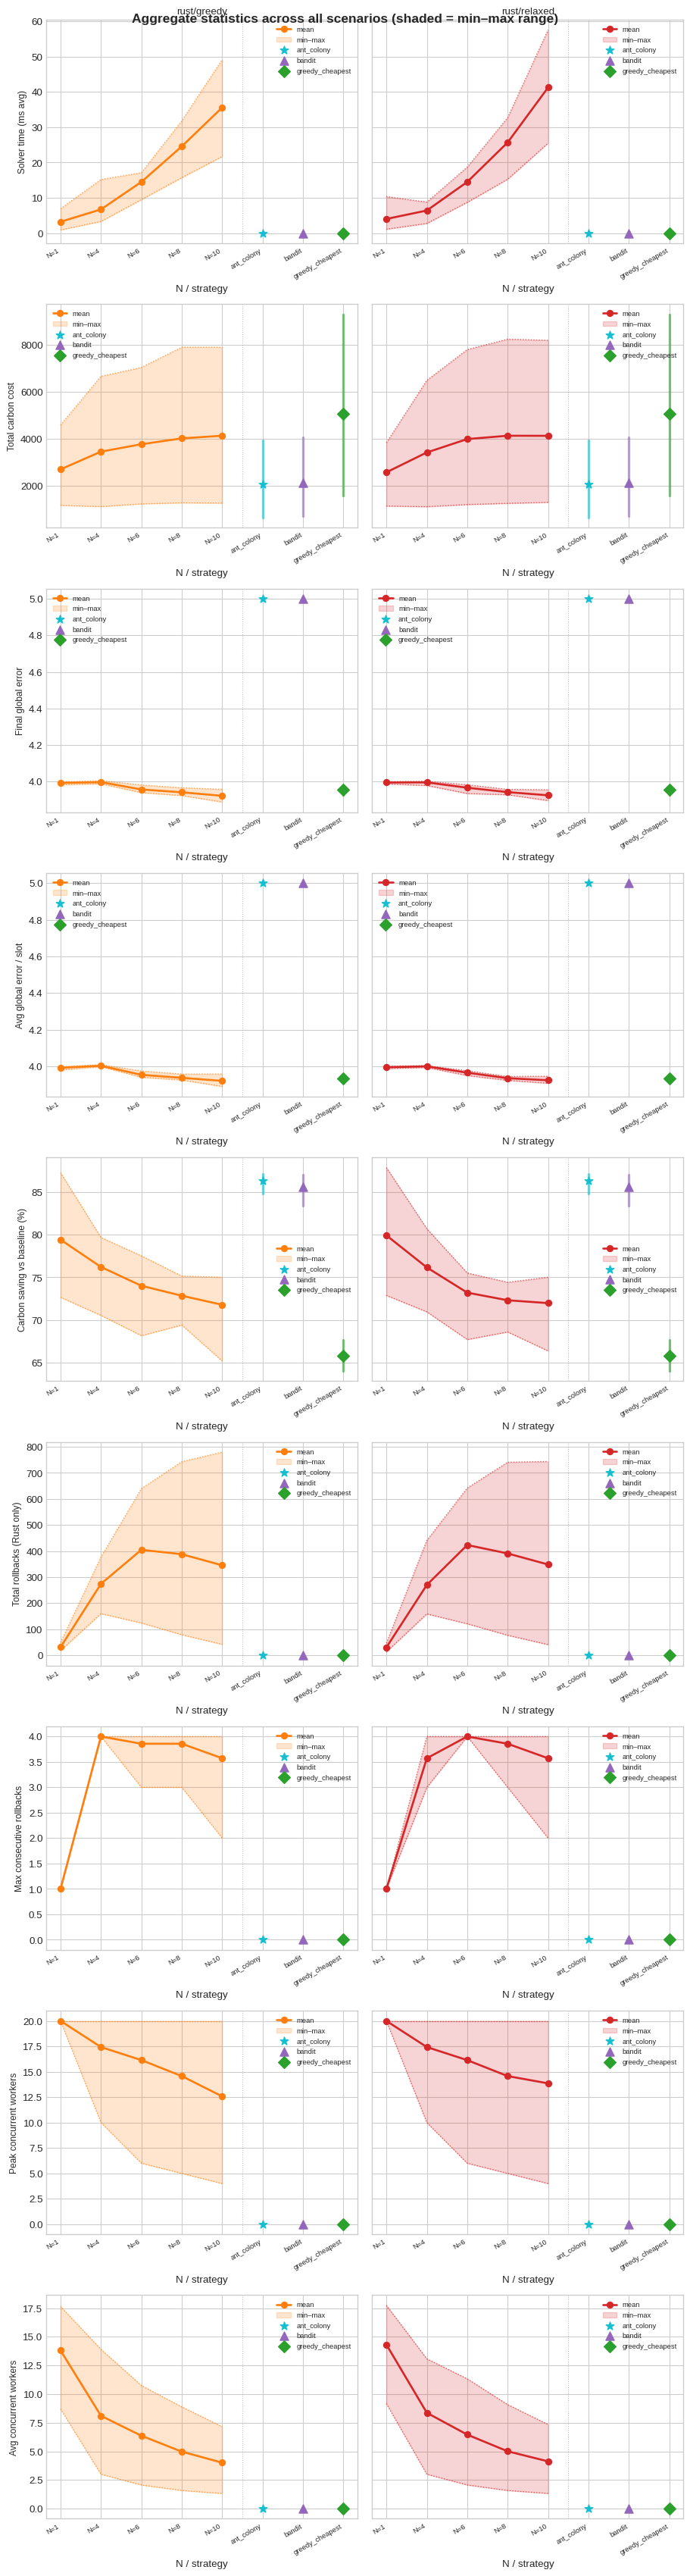

In [8]:
combos_sorted = sorted(combos)
fig_rows = len(METRICS)
fig_cols = max(len(combos_sorted), 1)

fig, axes = plt.subplots(
    fig_rows, fig_cols,
    figsize=(4.8 * fig_cols, 4.0 * fig_rows),
    squeeze=False,
    sharey="row",
)
fig.suptitle("Aggregate statistics across all scenarios (shaded = min–max range)\n",
             fontsize=13, fontweight="bold")

for row, m in enumerate(METRICS):
    for col, (backend, mode) in enumerate(combos_sorted):
        ax = axes[row][col]
        sub = df_modes[(df_modes["backend"] == backend) & (df_modes["infeasibility_mode"] == mode)]
        if sub.empty:
            ax.set_visible(False)
            continue
        grp = (
            sub.groupby("batch_size")[m["col"]]
            .agg(["min", "mean", "max"])
            .reset_index()
            .sort_values("batch_size")
        )
        xs = [bs_to_x[bs] for bs in grp["batch_size"]]
        color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
        ax.plot(xs, grp["mean"], marker="o", linewidth=2.0, color=color, label="mean")
        ax.fill_between(xs, grp["min"], grp["max"], alpha=0.2, color=color, label="min–max")
        ax.plot(xs, grp["min"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)
        ax.plot(xs, grp["max"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)

        # Strategy points: mean ± range across scenarios
        for strat in STRATEGY_NAMES:
            if df_strat.empty:
                continue
            vals = df_strat[df_strat["infeasibility_mode"] == strat][m["col"]].dropna()
            if vals.empty:
                continue
            x_pos = strat_to_x[strat]
            sty = _strategy_style(strat)
            sc = ax.scatter([x_pos], [vals.mean()], s=70, zorder=5,
                            color=sty["color"], marker=sty["marker"], label=strat)
            ax.plot([x_pos, x_pos], [vals.min(), vals.max()],
                    color=sty["color"], linewidth=2.5, alpha=0.6)

        if STRATEGY_NAMES and n_bs > 0:
            ax.axvline(x=n_bs - 0.5, linestyle=":", linewidth=0.8, alpha=0.5, color="gray")
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=7)
        ax.set_xlabel("N / strategy")
        if row == 0:
            ax.set_title(_series_label(backend, mode), fontsize=10)
        if col == 0:
            ax.set_ylabel(m["label"], fontsize=9)
        ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.show()


In [9]:
metric_cols = [m["col"] for m in METRICS]

overall_modes = (
    df_modes.groupby(["backend", "infeasibility_mode"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("Overall min / mean / max across ALL scenarios and ALL N values (modes):")
display(overall_modes)

if not df_strat.empty:
    overall_strat = (
        df_strat.groupby("infeasibility_mode")[metric_cols]
        .agg(["min", "mean", "max"])
        .round(4)
    )
    print("\nOverall min / mean / max across ALL scenarios (strategies):")
    display(overall_strat)


Overall min / mean / max across ALL scenarios and ALL N values (modes):


solver_time_ms_avg                  \
                                          min    mean     max   
backend infeasibility_mode                                      
rust    greedy_fallback                0.8957 16.9214 49.1954   
        relaxed_retry                  1.1122 18.3780 57.6077   

                           total_carbon_cost                      \
                                         min      mean       max   
backend infeasibility_mode                                         
rust    greedy_fallback            1099.4459 3607.1531 7911.6890   
        relaxed_retry              1094.0025 3640.8536 8253.8134   

                           final_global_error                \
                                          min   mean    max   
backend infeasibility_mode                                    
rust    greedy_fallback                3.8888 3.9624 4.0052   
        relaxed_retry                  3.8965 3.9652 4.0024   

                           avg_global_error_per_slot                \
                                                 min   mean    max   
backend infeasibility_mode                                           
rust    greedy_fallback                       3.8903 3.9613 4.0094   
        relaxed_retry                         3.9078 3.9638 4.0040   

                           carbon_cost_saving_vs_baseline_pct                  \
                                                          min    mean     max   
backend infeasibility_mode                                                      
rust    greedy_fallback                               65.2157 74.8571 87.2435   
        relaxed_retry                                 66.3982 74.7190 87.8322   

                           total_rollbacks                \
                                       min     mean  max   
backend infeasibility_mode                                 
rust    greedy_fallback                 18 288.6571  780   
        relaxed_retry                   13 292.5714  744   

                           max_consecutive_rollbacks             \
                                                 min   mean max   
backend infeasibility_mode                                        
rust    greedy_fallback                            1 3.2571   4   
        relaxed_retry                              1 3.2000   4   

                           peak_concurrent_workers              \
                                               min    mean max   
backend infeasibility_mode                                       
rust    greedy_fallback                          4 16.1429  20   
        relaxed_retry                            4 16.4000  20   

                           avg_concurrent_workers                 
                                              min   mean     max  
backend infeasibility_mode                                        
rust    greedy_fallback                    1.3257 7.4514 17.6465  
        relaxed_retry                      1.3257 7.6545 17.7435


Overall min / mean / max across ALL scenarios (strategies):


solver_time_ms_avg               total_carbon_cost  \
                                  min   mean    max               min   
infeasibility_mode                                                      
ant_colony                     0.0000 0.0000 0.0000          629.4620   
bandit                         0.0000 0.0000 0.0000          705.9702   
greedy_cheapest                0.0000 0.0000 0.0000         1560.1832   

                                       final_global_error                \
                        mean       max                min   mean    max   
infeasibility_mode                                                        
ant_colony         2035.3610 3940.3660             5.0000 5.0000 5.0000   
bandit             2102.8387 4047.5364             5.0000 5.0000 5.0000   
greedy_cheapest    5070.1067 9314.9737             3.9256 3.9556 3.9739   

                   avg_global_error_per_slot                \
                                         min   mean    max   
infeasibility_mode                                           
ant_colony                            5.0000 5.0000 5.0000   
bandit                                5.0000 5.0000 5.0000   
greedy_cheapest                       3.9132 3.9327 3.9450   

                   carbon_cost_saving_vs_baseline_pct                  \
                                                  min    mean     max   
infeasibility_mode                                                      
ant_colony                                    84.7786 86.3347 87.1330   
bandit                                        83.4070 85.5580 87.0481   
greedy_cheapest                               64.0667 65.7889 67.7094   

                   total_rollbacks            max_consecutive_rollbacks  \
                               min   mean max                       min   
infeasibility_mode                                                        
ant_colony                       0 0.0000   0                         0   
bandit                           0 0.0000   0                         0   
greedy_cheapest                  0 0.0000   0                         0   

                              peak_concurrent_workers             \
                     mean max                     min   mean max   
infeasibility_mode                                                 
ant_colony         0.0000   0                       0 0.0000   0   
bandit             0.0000   0                       0 0.0000   0   
greedy_cheapest    0.0000   0                       0 0.0000   0   

                   avg_concurrent_workers                
                                      min   mean    max  
infeasibility_mode                                       
ant_colony                         0.0000 0.0000 0.0000  
bandit                             0.0000 0.0000 0.0000  
greedy_cheapest                    0.0000 0.0000 0.0000